<a href="https://colab.research.google.com/github/adhammkhaled/Pattern-Recognition-Labs/blob/main/Image%20Classification%20and%20Segmentation/Skin_Cancer_Classification_and_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Skin Cancer Classification and Segmentation🎗️

##Import Libraries and Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import kagglehub
path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")
print("Path to dataset files:", path)

100%|██████████| 2.59G/2.59G [00:34<00:00, 81.5MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2


##Load CSV File and Print Head

In [2]:
# Load CSV File
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())
df.dropna(inplace=True)  # Drop missing values if any



          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0


##Define Image and Mask Paths and Remove Corrupt Data


In [3]:
image_dir = os.path.join(path, "images")
mask_dir = os.path.join(path, "masks")
class_names = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

# Convert one-hot encoding to integer labels
df["label"] = df[class_names].idxmax(axis=1).map(lambda x: class_names.index(x))


# Create lists of image paths and labels
images = df["image"].apply(lambda x: os.path.join(image_dir, x + ".jpg")).tolist()
masks = df["image"].apply(lambda x: os.path.join(mask_dir, x + "_segmentation.png")).tolist()
labels = df["label"].tolist()  # Now correctly using integer class labels

for i in range(5):
  print(f"Example Image Path {i}: {images[i]}")
  print(f"Example Mask Path {i}: {masks[i]}")
  print(f"Example Label {i}: {labels[i]}")


valid_samples = []
for img, mask in zip(images, masks):
    try:
        if os.path.exists(img) and os.path.exists(mask):
            Image.open(img).verify()
            Image.open(mask).verify()
            valid_samples.append((img, mask))
    except:
        print(f"Corrupt file detected: {img} or {mask}")

images, masks = zip(*valid_samples) if valid_samples else ([], [])
labels = [labels[i] for i in range(len(valid_samples))] if valid_samples else []



Example Image Path 0: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images/ISIC_0024306.jpg
Example Mask Path 0: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/masks/ISIC_0024306_segmentation.png
Example Label 0: 1
Example Image Path 1: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images/ISIC_0024307.jpg
Example Mask Path 1: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/masks/ISIC_0024307_segmentation.png
Example Label 1: 1
Example Image Path 2: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images/ISIC_0024308.jpg
Example Mask Path 2: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/masks/ISIC_0024308_segmentation.png
Example Label 2: 1
Example Image Path 3: /root/.cache

##Split Data

In [4]:
# Time to Split
train_imgs, temp_imgs, train_labels, temp_labels, train_masks, temp_masks = train_test_split(
    images, labels, masks, test_size=0.3, random_state=42, stratify=labels
)
val_imgs, test_imgs, val_labels, test_labels, val_masks, test_masks = train_test_split(
    temp_imgs, temp_labels, temp_masks, test_size=0.5, random_state=42, stratify=temp_labels
)
# Print dataset sizes
print(f"Dataset size: {len(df)}")
print(f"Training size: {len(train_imgs)}")
print(f"Validation size: {len(val_imgs)}")
print(f"Test size: {len(test_imgs)}")


Dataset size: 10015
Training size: 7010
Validation size: 1502
Test size: 1503


##Count number of Occurence of Each Label


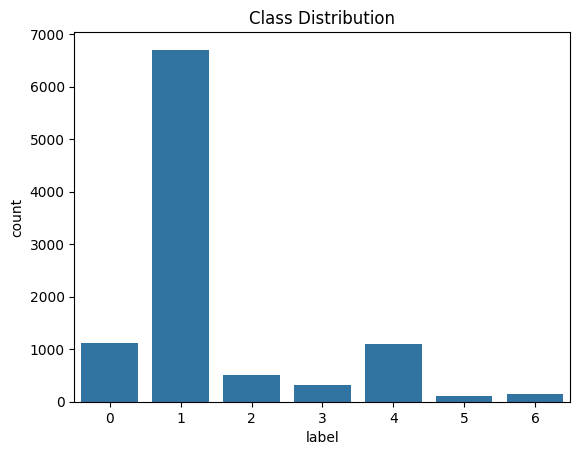

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()


##Define Data Transformation

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Flip images randomly
    transforms.RandomRotation(10),  # Rotate images randomly
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


##Create Dataset Class

In [7]:
class SkinDataset(Dataset):
    def __init__(self, image_paths, mask_paths, labels, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load the image (for classification)
        img = Image.open(self.image_paths[idx]).convert("RGB")

        # Load the mask (for segmentation)
        mask = Image.open(self.mask_paths[idx]).convert("L")  # Convert to grayscale

        # Apply transformations to the image
        if self.transform:
            img = self.transform(img)

        # Convert mask to tensor
        mask = torch.tensor(np.array(mask), dtype=torch.float32) / 255.0  # Normalize mask to [0,1]

        return img, mask, torch.tensor(self.labels[idx], dtype=torch.long)


# Create datasets
# Create datasets with masks included
train_dataset = SkinDataset(train_imgs, train_masks, train_labels, transform=train_transform)
val_dataset = SkinDataset(val_imgs, val_masks, val_labels, transform=val_test_transform)
test_dataset = SkinDataset(test_imgs, test_masks, test_labels, transform=val_test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



##Visualize Sample Images

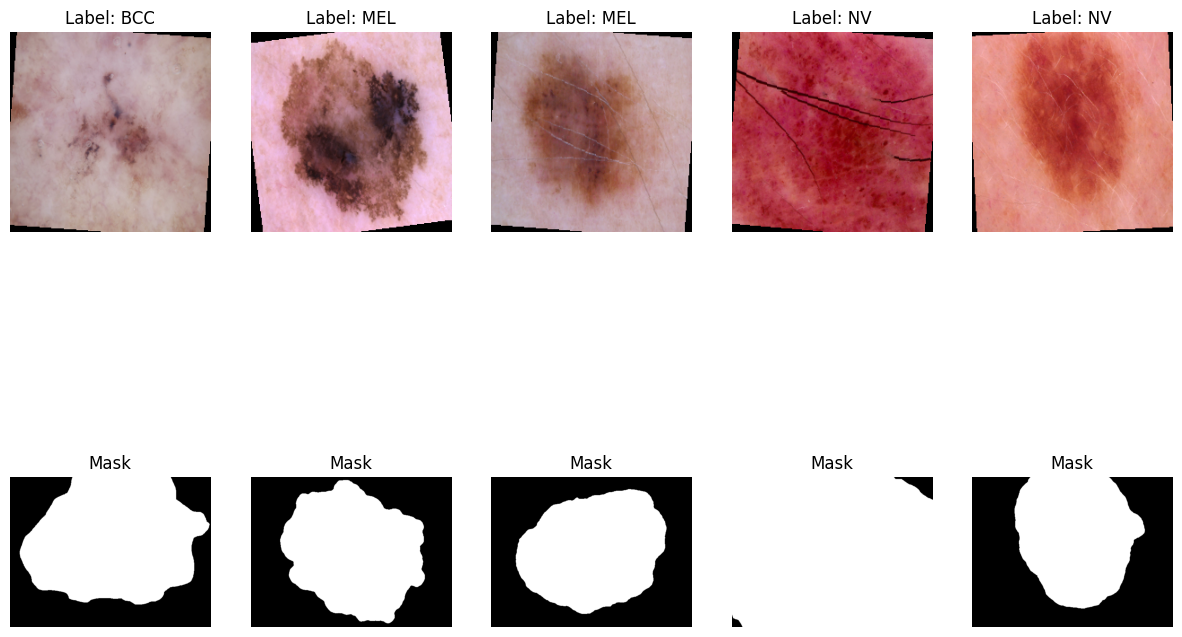

In [8]:
# Function to visualize images with their corresponding masks
def show_sample(dataset, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 10))

    for i in range(num_samples):
        img, mask, label = dataset[i]  # Unpack correctly
        img = img.permute(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)

        # Show image
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Label: {class_names[label]}")
        axes[0, i].axis("off")

        # Show corresponding mask
        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].set_title("Mask")
        axes[1, i].axis("off")

    plt.show()

# Show train samples
show_sample(train_dataset)


In [9]:
import torch
import torch.nn as nn
import torchvision.models as models

# pretrained ResNet18
resnet18 = models.resnet18(pretrained=True)

for param in resnet18.parameters():
    param.requires_grad = False  # Freeze all layers
for param in resnet18.layer4.parameters():
    param.requires_grad = True

num_classes = 7  # elskin cancer classed
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = resnet18.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=1e-4)

# Training
for epoch in range(10):
    resnet18.train()
    running_loss = 0.0

    for images, masks, labels in train_loader:  # images and labels for classification
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet18(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/10] Loss: {running_loss/len(train_loader):.4f}")

print("Training Done ??")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


Epoch [1/10] Loss: 0.6947
Epoch [2/10] Loss: 0.4589
Epoch [3/10] Loss: 0.3590
Epoch [4/10] Loss: 0.2810
Epoch [5/10] Loss: 0.2255
Epoch [6/10] Loss: 0.1852
Epoch [7/10] Loss: 0.1763
Epoch [8/10] Loss: 0.1494
Epoch [9/10] Loss: 0.1237
Epoch [10/10] Loss: 0.0861
Training Done ??


In [11]:
total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total Parameters: {total_params:,}")


Total Parameters: 11,180,103


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

resnet18.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, _, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = resnet18(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [15]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Accuracy: 83.23%


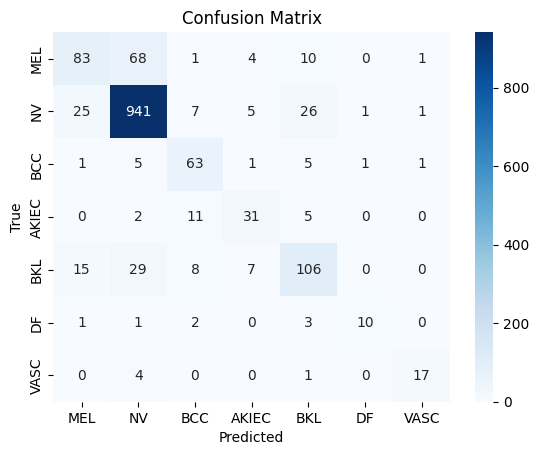

In [16]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [17]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

         MEL       0.66      0.50      0.57       167
          NV       0.90      0.94      0.92      1006
         BCC       0.68      0.82      0.75        77
       AKIEC       0.65      0.63      0.64        49
         BKL       0.68      0.64      0.66       165
          DF       0.83      0.59      0.69        17
        VASC       0.85      0.77      0.81        22

    accuracy                           0.83      1503
   macro avg       0.75      0.70      0.72      1503
weighted avg       0.83      0.83      0.83      1503

